In [1]:
import pandas as pd
from tools.utils import *
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import paired_cosine_distances
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import numpy as np

import torch
import spacy
sns.set()

In [3]:
path = Path('annotations/sent_sim_eval/xlsx')
df_cosm = pd.read_excel(path / 'modifications_cosmetic.xlsx', sheet_name='Sheet2')
df_subs = pd.read_excel(path / 'modifications_meaning.xlsx', sheet_name='Sheet2')
df_meaning = pd.read_excel(path / 'modifications_meaning 2.xlsx', sheet_name='Sheet2')
df_x = pd.read_excel(path / 'modifications_X_full.xlsx', sheet_name='Sheet2')

In [4]:
df_cosm['type'] = 'cosmetic'
df_subs['type'] = 'subs'
df_meaning['type'] = 'meaning'
df_x['type'] = 'x'

In [5]:
# choose the embedding model: "nomic-embed-text-v1.5" | "qwen3-embedding-0.6b" | "embeddinggemma" | "bge-large-en-v1.5"
embedding_model_name = "bge-large-en-v1.5"
model, prefix = load_embedding_model(embedding_model_name)


In [6]:
def compute_distances(df,model,col1, col2, prefix=prefix):
    
    embeddings1 = model.encode([ prefix + s for s in df[col1].tolist()])
    embeddings2 = model.encode([ prefix + s for s in df[col2].tolist()])

    distances = 1 - paired_cosine_distances(embeddings1,embeddings2)
    return distances


In [7]:
df_meaning['distances'] = compute_distances(df_meaning,model,'Original','Human Modified')
df_subs['distances'] = compute_distances(df_subs,model,'Original','Human Modified')
df_cosm['distances'] = compute_distances(df_cosm,model,'Original','Human Modified')
df_x['distances'] = compute_distances(df_x,model,'Before','After')

<Axes: xlabel='type', ylabel='distances'>

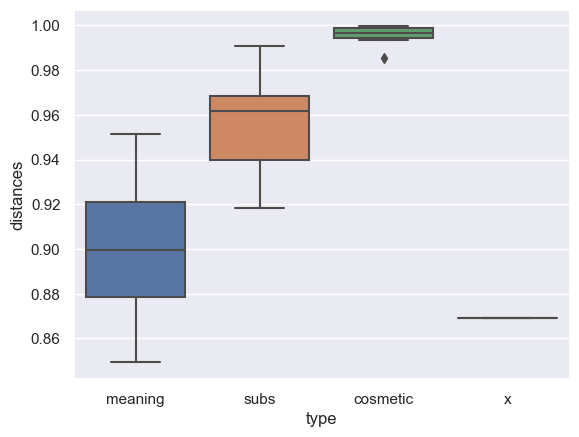

In [8]:
data = pd.concat([df_meaning,df_subs,df_cosm,df_x],axis=0, ignore_index=True)
sns.boxplot(x='type', y='distances', data=data)

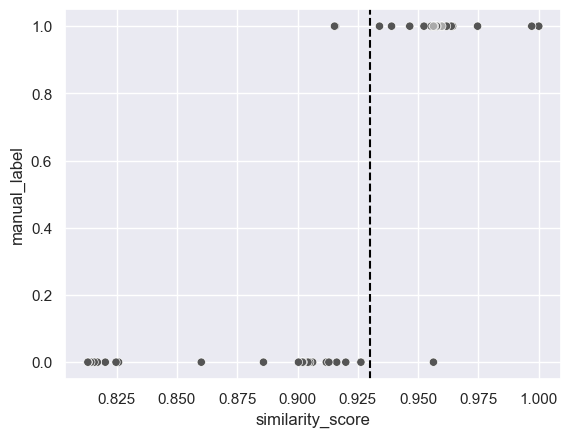

In [10]:
from matplotlib import pyplot as plt
pair_annotations_1 = pd.read_excel('annotations/sent_sim_eval/xlsx/pairs_to_annotate_TS.xlsx', sheet_name='pairs_to_annotate')
pair_annotations_2 = pd.read_excel('annotations/sent_sim_eval/xlsx/pairs_to_annotate_round_2_TS.xlsx', sheet_name='pairs_to_annotate_round_2')
pair_annotations = pd.concat([pair_annotations_1,pair_annotations_2],axis=0, ignore_index=True)
pair_annotations['colour'] = 'black'
pair_annotations.loc[pair_annotations.label != pair_annotations.manual_label,'colour'] = 'gray'
lines = sns.scatterplot(y='manual_label', x='similarity_score',hue='colour',data=pair_annotations, legend=False, palette='gray')
plt.axvline(.93, 0, 1, color='black', linestyle='--')
fig = lines.get_figure()
fig.savefig("figures/jels/Figure_7_left_gray.png", dpi=300, bbox_inches='tight')

In [11]:
pair_annotations['score'] = 0
pair_annotations.loc[pair_annotations.similarity_score >= 0.93,'score'] = 1

In [12]:
from sklearn.metrics import classification_report
print(classification_report(pair_annotations.manual_label, pair_annotations.score))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        26
           1       0.96      0.92      0.94        24

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score
results = []
for thr in np.linspace(0.9,1,11):
    pair_annotations['score'] = 0
    pair_annotations.loc[pair_annotations.similarity_score >= thr,'score'] = 1
    f1 = f1_score(pair_annotations.manual_label, pair_annotations.score)
    precision = precision_score(pair_annotations.manual_label, pair_annotations.score)
    recall = recall_score(pair_annotations.manual_label, pair_annotations.score)
    results.append((thr, f1, precision, recall))


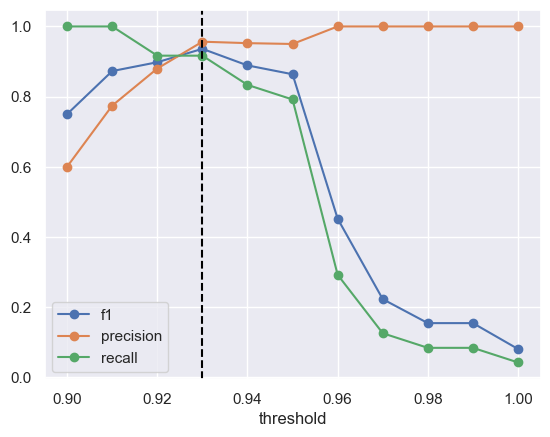

In [14]:
ax = pd.DataFrame(results, columns=['threshold', 'f1', 'precision', 'recall']
                  ).plot(x='threshold', y=['f1', 'precision', 'recall'], marker='o') # ,color=['black', 'gray', 'lightgray']
plt.axvline(.93, 0, 1, color='black', linestyle='--')
fig = ax.get_figure()
fig.savefig("figures/jels/Figure_7_right.png", dpi=300)

In [216]:
sentences = list(Path('xls_files/sentences').glob('*.xlsx'))

In [217]:
sentences

[PosixPath('xls_files/sentences/modifications_meaning_limitation[7].xlsx'),
 PosixPath('xls_files/sentences/modifications_X_jurisdiction[1].xlsx'),
 PosixPath('xls_files/sentences/modifications_meaning_lang[37].xlsx'),
 PosixPath('xls_files/sentences/modifications_meaning_arb[92].xlsx'),
 PosixPath('xls_files/sentences/modifications_cosmetic_mod[97].xlsx')]

In [219]:
dfs = []
for sentence in sentences:
    df = pd.read_excel(sentence, sheet_name='Sheet2')
    df['similarity_score'] = compute_distances(df,model,'Original','Modified')
    dfs.append(df)


In [220]:
pd.concat(dfs, axis=0, ignore_index=True).to_csv('sentences_similarity.csv', index=False)